In [10]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Ridge-Regression.csv to Ridge-Regression.csv


In [6]:
#Read exel file
df = pd.read_csv('Ridge-Regression.csv')
# Display first  rows
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


In [7]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB
None

Summary Statistics:
                id  avg_work_hours_per_day  avg_rest_hours_per_day  \
count  10000.00000            10000.000000            10000.000000   
mean   15000.50000                9.211857                5.964582   
std     

In [8]:
df.shape

(10000, 8)

In [9]:
df.isnull().any()

,0
id,False
gender,False
occupation_type,False
avg_work_hours_per_day,False
avg_rest_hours_per_day,False
avg_sleep_hours_per_day,False
avg_exercise_hours_per_day,False
age_at_death,False


In [11]:
# -------------------------------------------------
# STEP 3: DATA UNDERSTANDING
# -------------------------------------------------

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Information about dataset
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(10000, 8)

Column Names:
Index(['id', 'gender', 'occupation_type', 'avg_work_hours_per_day',
       'avg_rest_hours_per_day', 'avg_sleep_hours_per_day',
       'avg_exercise_hours_per_day', 'age_at_death'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 62

In [12]:
# Fill numerical missing values with mean
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify again
print(df.isnull().sum())

id                            0
gender                        0
occupation_type               0
avg_work_hours_per_day        0
avg_rest_hours_per_day        0
avg_sleep_hours_per_day       0
avg_exercise_hours_per_day    0
age_at_death                  0
dtype: int64


In [13]:
# --------------------------------------------
# STEP 5: ENCODE CATEGORICAL VARIABLES
# --------------------------------------------

label_encoder = LabelEncoder()

# Encode gender
df['gender'] = label_encoder.fit_transform(df['gender'])

# Encode occupation
df['occupation_type'] = label_encoder.fit_transform(df['occupation_type'])

# Display encoded dataset
df.head()


,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,0,12,6.60,10.92,5.38,1.10,88
1,10002,1,9,9.65,7.65,6.31,0.39,76
2,10003,0,7,13.77,1.00,8.02,1.21,78
3,10004,0,5,10.94,5.18,7.59,0.29,74
4,10005,1,3,9.81,5.11,7.38,1.70,78


In [14]:
# ================================================
# STEP 6: DEFINE X AND Y
# ================================================

# Drop target + id column from features
X = df.drop(['age_at_death', 'id'], axis=1)

y = df['age_at_death']

print("Independent Variables:")
print(X.head())
print("\nX shape:", X.shape)

print("\nTarget Variable:")
print(y.head())
print("\ny shape:", y.shape)

Independent Variables:
   gender  occupation_type  avg_work_hours_per_day  avg_rest_hours_per_day  \
0       0               12                    6.60                   10.92   
1       1                9                    9.65                    7.65   
2       0                7                   13.77                    1.00   
3       0                5                   10.94                    5.18   
4       1                3                    9.81                    5.11   

   avg_sleep_hours_per_day  avg_exercise_hours_per_day  
0                     5.38                        1.10  
1                     6.31                        0.39  
2                     8.02                        1.21  
3                     7.59                        0.29  
4                     7.38                        1.70  

X shape: (10000, 6)

Target Variable:
0    88
1    76
2    78
3    74
4    78
Name: age_at_death, dtype: int64

y shape: (10000,)


In [15]:
# -------------------------------------------------
# STEP 7: TRAIN TEST SPLIT
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(8000, 6)
Testing Data Shape:
(2000, 6)


In [17]:

# STEP 8: FEATURE SCALING
# -------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
# STEP 9: FIND BEST ALPHA
# -------------------------------------------------

alpha_values = [0.01, 0.1, 1, 10, 50, 100]

ridge_cv = RidgeCV(alphas=alpha_values)

ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_

print("Best Alpha Value:")
print(best_alpha)

Best Alpha Value:
0.01


In [19]:
# STEP 10: TRAIN RIDGE REGRESSION MODEL
# -------------------------------------------------

ridge_model = Ridge(alpha=best_alpha)

ridge_model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [20]:
# STEP 11: PREDICTION
# -------------------------------------------------

y_pred = ridge_model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[81.84143482 77.15261673 81.60373674 89.33601113 76.7535121  77.1423002
 79.19086984 64.44692635 81.63962386 80.09879906]


In [21]:
# ================================================
# STEP 12: MODEL EVALUATION
# ================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("---------------------------")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

Model Evaluation Metrics
---------------------------
MAE  : 7.78
MSE  : 105.12
RMSE : 10.25
R2 Score : 0.2845


In [22]:
# STEP 13: COEFFICIENT ANALYSIS
# ================================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

print(coefficients)

                      Feature  Coefficient
0                      gender    -1.660361
1             occupation_type     0.254830
2      avg_work_hours_per_day  -169.497919
3      avg_rest_hours_per_day  -178.623328
4     avg_sleep_hours_per_day  -126.685107
5  avg_exercise_hours_per_day   -51.368225


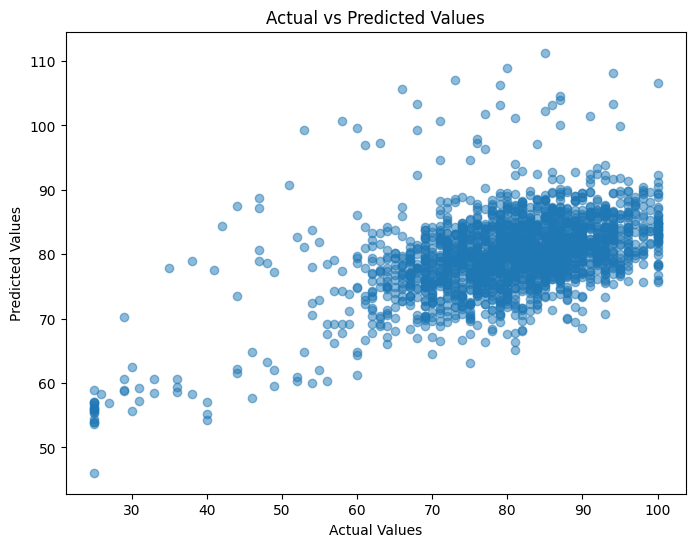

In [23]:
# STEP 14: ACTUAL VS PREDICTED GRAPH
# ================================================


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

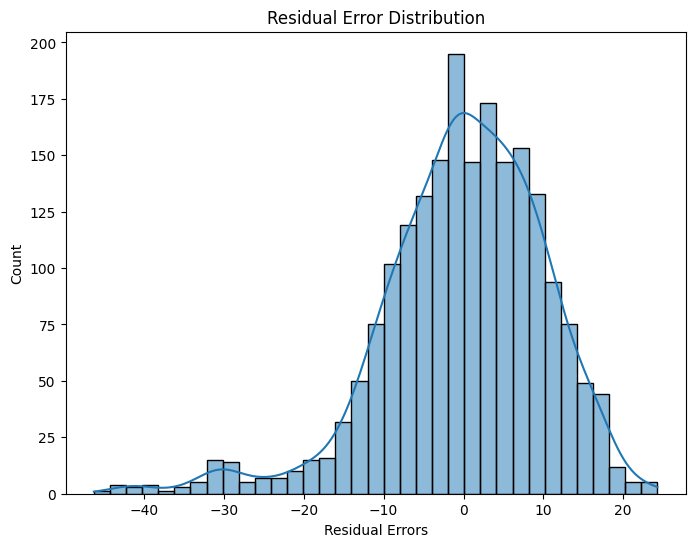

In [24]:

# STEP 15: RESIDUAL ERROR PLOT
# ================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Residual Errors")

plt.show()

In [25]:
# STEP 16: ACTUAL VS PREDICTED TABLE
# ================================================

comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

    Actual_Value  Predicted_Value
0             88        81.841435
1             84        77.152617
2             96        81.603737
3             87        89.336011
4             85        76.753512
5             73        77.142300
6             74        79.190870
7             70        64.446926
8             90        81.639624
9             77        80.098799
10            69        79.379184
11            56        78.548643
12            78        87.492672
13            87        83.600219
14            92        86.392540
15            71        86.274183
16            62        73.531147
17            80        79.790341
18            97        88.029196
19            84        73.871075
